# Set Working Directory to Project Root

All modules in this project use absolute imports. Therefore, the working directory is set to the project root to ensure that all module references can be resolved correctly.

In [1]:
# Resolve the repository from this notebook's directory or the repository root.
from pathlib import Path
import os
import sys
_start = Path.cwd().resolve()
repo_root = next(p for p in (_start, *_start.parents) if (p / "src" / "weed_ca.py").is_file())
os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from pathlib import Path
import os

repo_root = Path.cwd().resolve()
os.chdir(repo_root)

print(Path.cwd())

d:\1_Document\A-02_Notebooks\1_UWA_Learning_Archive\02_Units\Y1S2_CITS4403 - Computational Modelling\Project\Repo


# Load Geo Data

The locality polygons have been preprocessed and integrated with population density data. The resulting GeoDataFrame contains both spatial geometry and population-related attributes required for model initialisation.

## Data Sources

- **Population Data:** [Australian Bureau of Statistics (ABS)](https://www.abs.gov.au/statistics/people/population/population-census/latest-release)
- **Locality Polygons:** [WA Localities](https://catalogue.data.wa.gov.au/dataset/localities)

In [13]:
from utils.data_loader import load_locality_data

localities = load_locality_data()

metro = localities[
    localities["postcode"].astype(int).between(6000,6199)
].copy()

# Convert Geo Data to Weed Index Data

The initial Weed Index is calculated from population density using an exponential decay function. The resulting Weed Index is then assigned to the corresponding spatial units for subsequent grid generation and simulation.

In [3]:
import utils.weed_simulation_tools as wst

metro['weed_index'] = wst.weed_index_initialize(density=metro['population_density_km2'],
                                            pressure_coef=0.05,
                                            w_min=0.05,
                                            w_max=1)

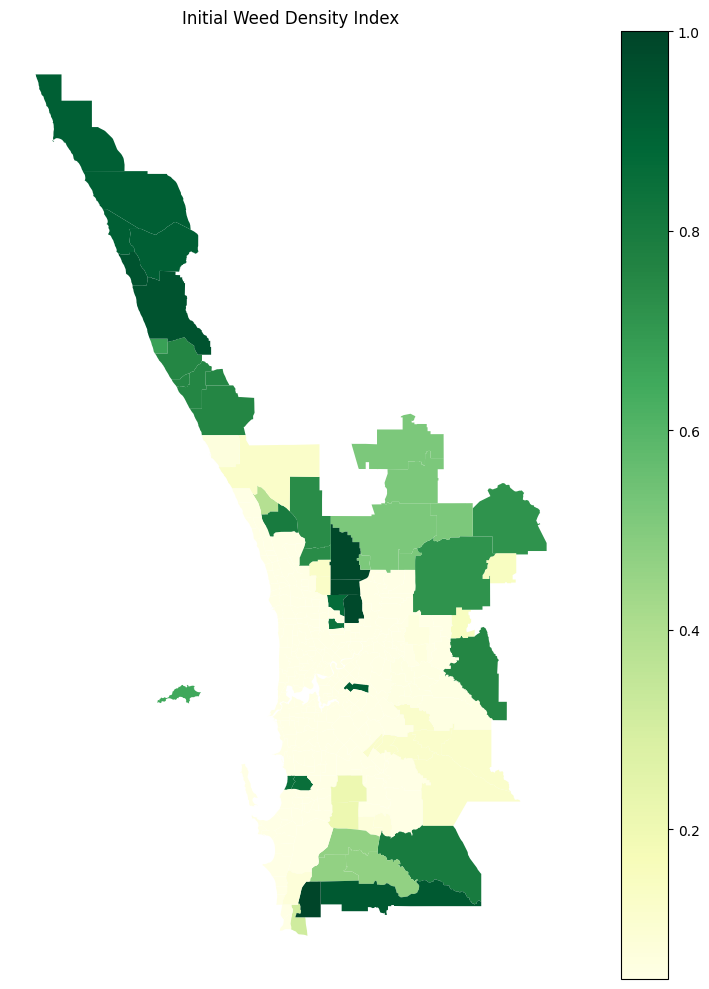

In [4]:
# Check the convertion result
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

metro.plot(
    column="weed_index",
    cmap="YlGn",
    legend=True,
    ax=ax,
    edgecolor="none"
)

ax.set_title("Initial Weed Density Index")
ax.set_axis_off()

plt.tight_layout()
plt.show()

# Polygon-to-Grid Conversion

The polygon-to-grid conversion is encapsulated in the `polygon_to_grid()` function, which provides a simplified interface for rasterising polygons with their corresponding Weed Index values.

The function returns:

- `weed_grid`: the Weed Index values represented as a regular spatial grid.
- `valid_mask`: a mask identifying valid cells within the modelled area.
- `transform`: the spatial transformation used to map grid coordinates to the original spatial reference system.

In [7]:
import numpy as np

weed_grid, valid_mask, transform = wst.polygon_to_grid(
    metro,
    cell_size=1000
)

print(weed_grid.shape)
print(np.nanmin(weed_grid))
print(np.nanmax(weed_grid))

(203, 124)
0.05
1.0


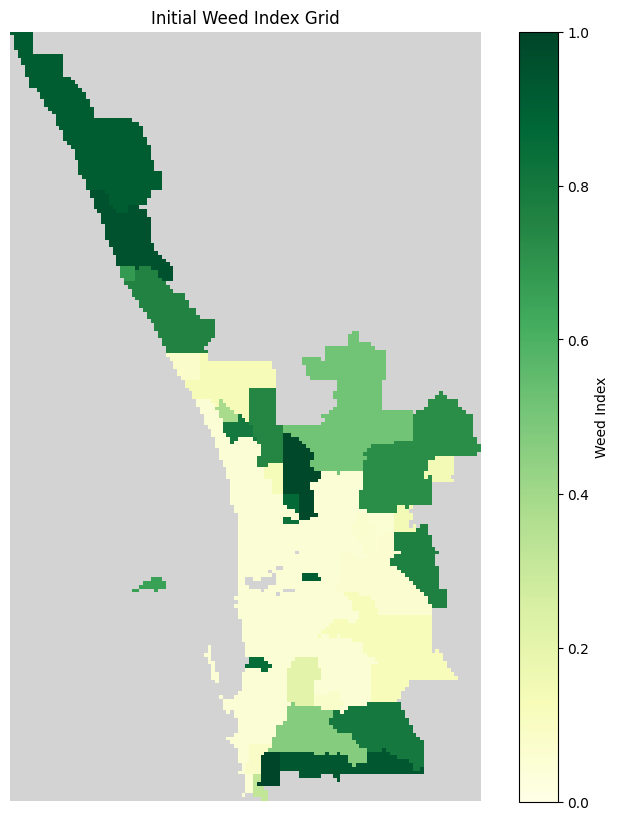

In [8]:
import matplotlib.pyplot as plt

cmap = plt.cm.YlGn.copy()
cmap.set_bad("lightgray")

plt.figure(figsize=(10, 10))

plt.imshow(
    weed_grid,
    cmap=cmap,
    vmin=0,
    vmax=1
)

plt.colorbar(label="Weed Index")

plt.title("Initial Weed Index Grid")
plt.axis("off")

plt.show()

# Initialize Cellular Automaton Object

The previously defined spatial preprocessing and simulation components are encapsulated in the WeedCA class. The Cellular Automaton is initialised from the locality polygons using the specified model parameters.

The main model parameters are:

- `pressure_coef`: controls the sensitivity of the initial Weed Index to population density. A larger value results in a faster decrease in the initial Weed Index as population density increases.

- `cell_size`: defines the spatial resolution of the Cellular Automaton grid, in metres.

- `growth_rate`: controls the rate of natural weed growth per timestep.

- `diffusion_rate`: controls the strength of spatial propagation between neighbouring cells.

The model is then initialised using the processed locality polygons and these parameters.

In [ ]:
import importlib
import src.weed_ca

importlib.reload(src.weed_ca)

weedca = src.weed_ca.WeedCA.polygon_to_weedca(metro, 
                                                  pressure_coef=0.05,
                                                  cell_size=500,
                                                  growth_rate=0.02,
                                                  diffusion_rate=0.01)


# Simulation and Animation

The Cellular Automaton is simulated for a user-defined number of timesteps, with the simulation results visualised as an animation.

The number of timesteps and animation frame rate can be specified through the steps and fps parameters, respectively.

In [16]:

modes = ['growth', 'diffusion']
weedca.animate(frames=108, fps=20, modes=modes)

# Introducing Management Policy Functions

Management policies are implemented as user-defined functions and registered with the WeedCA object. Once a policy function is registered, the Cellular Automaton automatically applies the corresponding removal strategy and calculates the associated management cost during each simulation timestep.

This policy-based design allows different management strategies and cost structures to be evaluated without modifying the underlying Cellular Automaton model.

In [17]:
import numpy as np

def simple_removal(weed_grid, mask):
    weed_grid[~mask] = 0
    diff = weed_grid * 0.001
    cost = float(np.sum(diff * 200))

    return diff, cost

weedca.register_policy(simple_removal)

In [18]:
modes = ['growth', 'diffusion', 'removal']
weedca.animate(frames=108, fps=20, modes=modes)

# Further Research: Cost Optimization